C:\Users\student\anaconda3\envs\dl\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] 找不到指定的程序。
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
C:\Users\student\anaconda3\envs\dl\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] 找不到指定的程序。
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
C:\Users\student\anaconda3\envs\dl\lib\site-packages\torch_geometric\typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: [WinError 127] 找不到指定的程序。
  warnings.warn(
C:\Users\student\anaconda3\envs\dl\lib\site-packages\torch_geometric\typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: [WinError 127] 找不到指定的程序。
  warnings.warn(

找到可用的中文字型: Microsoft YaHei
使用設備: cuda
成功讀取數據文件

創建地點關係圖...
有859066個用戶訪問了多個地點
數據對象創建完成: Data(x=[838, 1], edge_index=[2, 154534], edge_attr=[154534])
模型結構: GNN(
  (conv1): GCNConv(1, 16)
  (conv2): GCNConv(16, 8)
)

開始訓練模型...
Epoch 020, Loss: 1.0009
Epoch 040, Loss: 0.9899
Epoch 060, Loss: 0.9948
Epoch 080, Loss: 0.9953
Epoch 100, Loss: 0.9942
Epoch 120, Loss: 0.9916
Epoch 140, Loss: 0.9863
Epoch 160, Loss: 0.9879
Epoch 180, Loss: 0.9864
Epoch 200, Loss: 0.9872


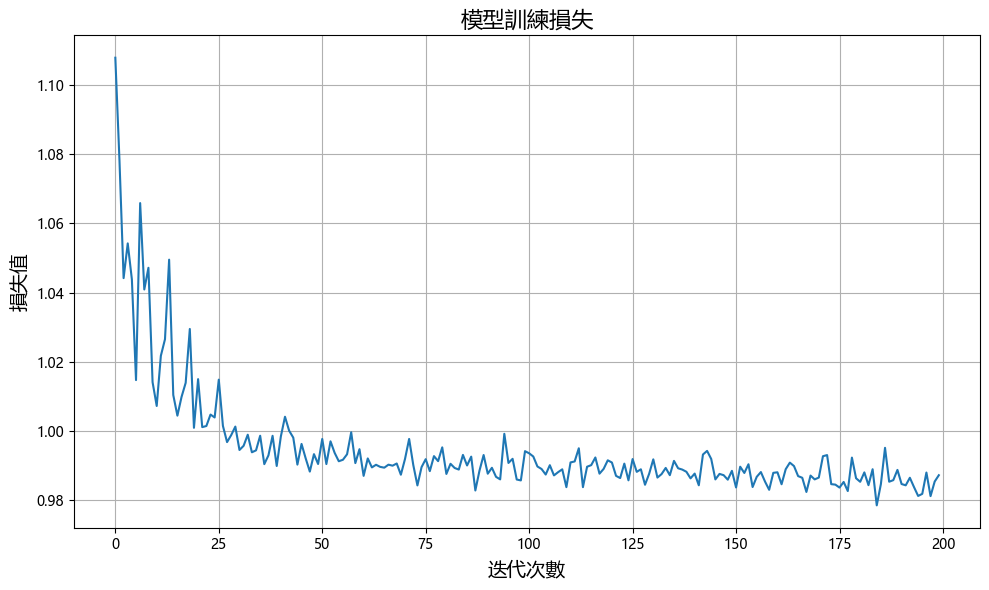

聚類輪廓係數: 0.5545


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
import warnings
import matplotlib.font_manager as fm
warnings.filterwarnings('ignore')

# 查找系統可用的中文字型
def find_chinese_font():
    # 常見的中文字型列表
    chinese_fonts = [
        'SimHei', 'Microsoft YaHei', '微軟正黑體', 'Microsoft JhengHei',
        'PingFang TC', 'PingFang SC', 'Noto Sans CJK TC', 'Noto Sans CJK SC',
        'Heiti TC', 'Heiti SC', 'WenQuanYi Micro Hei', 'Source Han Sans CN', 
        'Source Han Sans TW', 'Hiragino Sans GB'
    ]
    
    # 獲取所有系統字型
    font_paths = fm.findSystemFonts()
    system_fonts = [fm.get_font(font).family_name for font in font_paths]
    
    # 尋找可用的中文字型
    for font in chinese_fonts:
        if font in system_fonts:
            print(f"找到可用的中文字型: {font}")
            return [font]
    
    # 如果找不到中文字型，則返回空列表，使用matplotlib默認字型
    print("找不到中文字型，將使用預設字型。中文可能無法正確顯示。")
    return []

# 設置中文字型支持
chinese_font = find_chinese_font()
if chinese_font:
    plt.rcParams['font.sans-serif'] = chinese_font
    plt.rcParams['axes.unicode_minus'] = False
else:
    # 如果沒有找到中文字型，嘗試使用一個通用配置
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False
    print("使用DejaVu Sans作為後備字型。中文可能無法正確顯示，但程式仍會繼續執行。")

# 檢查是否有GPU可用
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用設備: {device}")

# 讀取數據
df = pd.read_csv('838-所有評論原始資料.csv', encoding='utf-8')
print("成功讀取數據文件")

# 創建地點之間的關係圖
print("\n創建地點關係圖...")
# 找出有多個評論的用戶
user_locations = df.groupby('user_id')['gmap_location'].apply(list)
user_locations = user_locations[user_locations.apply(len) > 1]
print(f"有{len(user_locations)}個用戶訪問了多個地點")

# 創建地點之間的轉換圖
G = nx.DiGraph()
for locations in user_locations:
    for i in range(len(locations) - 1):
        source = locations[i]
        target = locations[i+1]
        if G.has_edge(source, target):
            G[source][target]['weight'] += 1
        else:
            G.add_edge(source, target, weight=1)

# 提取節點和邊的信息
nodes = list(G.nodes())
node_mapping = {node: i for i, node in enumerate(nodes)}
edge_index = []
edge_weight = []

for source, target, data in G.edges(data=True):
    edge_index.append([node_mapping[source], node_mapping[target]])
    edge_weight.append(data['weight'])

# 轉換為PyTorch Geometric格式
edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
edge_weight = torch.tensor(edge_weight, dtype=torch.float)

# 創建節點特徵
node_features = []
for node in nodes:
    # 使用該地點的平均評分作為特徵
    avg_score = df[df['gmap_location'] == node]['score'].mean()
    node_features.append([avg_score])

x = torch.tensor(node_features, dtype=torch.float)

# 標準化節點特徵
x = (x - x.mean()) / (x.std() + 1e-8)

# 創建PyTorch Geometric數據對象
data = Data(x=x, edge_index=edge_index, edge_attr=edge_weight)
print(f"數據對象創建完成: {data}")

# 為鏈接預測拆分邊集合
edge_index_np = edge_index.numpy().T
n_edges = edge_index.size(1)
train_edges_idx, test_edges_idx = train_test_split(np.arange(n_edges), test_size=0.2)

# 這裡先不移動到設備，後面再統一處理
train_edge_index = torch.tensor(edge_index_np[train_edges_idx].T, dtype=torch.long)
test_edge_index = torch.tensor(edge_index_np[test_edges_idx].T, dtype=torch.long)
train_edge_weight = edge_weight[train_edges_idx]
test_edge_weight = edge_weight[test_edges_idx]

# 定義GNN模型
class GNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GNN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
    
    def forward(self, x, edge_index, edge_weight=None):
        x = self.conv1(x, edge_index, edge_weight)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index, edge_weight)
        return x

# 初始化模型
model = GNN(in_channels=1, hidden_channels=16, out_channels=8)
print(f"模型結構: {model}")

# 將數據和模型移動到設備
model = model.to(device)
data.x = data.x.to(device)
data.edge_index = data.edge_index.to(device)
data.edge_attr = data.edge_attr.to(device)
train_edge_index = train_edge_index.to(device)
test_edge_index = test_edge_index.to(device)
train_edge_weight = train_edge_weight.to(device)
test_edge_weight = test_edge_weight.to(device)

# 定義優化器
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 訓練模型（無監督學習 - 自編碼器風格）
def train():
    model.train()
    optimizer.zero_grad()
    # 前向傳播
    z = model(data.x, train_edge_index, train_edge_weight)
    # 計算重構損失（這裡使用節點特徵的自我預測作為簡單示例）
    loss = F.mse_loss(z, data.x.repeat(1, 8))
    loss.backward()
    optimizer.step()
    return loss.item()

# 訓練模型
print("\n開始訓練模型...")
losses = []
for epoch in range(200):
    loss = train()
    losses.append(loss)
    if (epoch + 1) % 20 == 0:
        print(f'Epoch {epoch+1:03d}, Loss: {loss:.4f}')

# 繪製訓練損失曲線
plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.title('模型訓練損失', fontsize=16)
plt.xlabel('迭代次數', fontsize=14)
plt.ylabel('損失值', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

# 獲取節點嵌入 - 修正為先在設備上運算，再轉回CPU
model.eval()
with torch.no_grad():
    # 確保所有輸入都在同一設備上
    node_embeddings = model(data.x, data.edge_index, data.edge_attr).cpu().numpy()

# 使用PCA降維以便可視化
pca = PCA(n_components=2)
node_embeddings_2d = pca.fit_transform(node_embeddings)

# 使用K-means聚類
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(node_embeddings)

# 計算聚類評估指標
silhouette_avg = silhouette_score(node_embeddings, clusters)
print(f"聚類輪廓係數: {silhouette_avg:.4f}")

# 新增功能：基於自然語言的景點推薦系統
def recommend_by_text(user_input, df, nodes, node_embeddings, node_mapping, top_n=5):
    """
    基於自然語言輸入推薦景點
    
    參數:
    - user_input: 用戶輸入的自然語言描述，如"我想要去玩水"
    - df: 包含評論數據的DataFrame
    - nodes: 所有景點名稱列表
    - node_embeddings: 模型學習的景點嵌入向量
    - node_mapping: 景點名稱到索引的映射字典
    - top_n: 要返回的推薦數量
    
    返回:
    - 推薦景點列表，包含相關度分數
    """
    # 定義一些關鍵詞映射，根據不同主題擴展關鍵詞
    keyword_mapping = {
        "玩水": ["水", "海", "海灘", "游泳", "浮潛", "衝浪", "溫泉", "瀑布", "河", "湖", "潭", "游泳池", "戲水"],
        "登山": ["山", "爬山", "登山", "健行", "步道", "森林", "自然", "風景", "登頂", "郊山", "高山"],
        "文化": ["廟宇", "寺廟", "古蹟", "歷史", "文化", "藝術", "博物館", "展覽", "廟", "文化財", "古城", "老街"],
        "美食": ["美食", "小吃", "夜市", "餐廳", "飲食", "特產", "小吃街", "美味", "餐點", "食物", "特色餐"],
        "購物": ["購物", "商場", "市場", "紀念品", "伴手禮", "夜市", "精品", "買", "商店街", "特產", "賣"],
        "放鬆": ["放鬆", "休閒", "溫泉", "SPA", "度假", "渡假村", "療癒", "舒緩", "舒適", "休息", "避暑"],
        "拍照": ["拍照", "風景", "美景", "景色", "打卡", "景點", "自拍", "攝影", "日落", "日出", "壯麗", "美麗"],
        "親子": ["親子", "兒童", "小孩", "家庭", "遊樂", "遊戲", "互動", "教育", "體驗", "適合小朋友", "適合家庭"],
    }
    
    # 提取輸入中的關鍵字
    input_keywords = []
    for category, keywords in keyword_mapping.items():
        for keyword in keywords:
            if keyword in user_input:
                if not any(k in input_keywords for k in keywords):
                    input_keywords.extend(keywords)
                break
    
    # 如果沒有找到特定關鍵字，提取所有非停用詞作為關鍵字
    if not input_keywords:
        # 簡單的中文停用詞
        stopwords = ["我", "想", "要", "去", "的", "是", "有", "在", "來", "能", "會", "可以", "哪裡", "推薦", "地方"]
        input_keywords = [word for word in user_input if word not in stopwords and len(word.strip()) > 0]
    
    # 去除重複關鍵詞並打印
    input_keywords = list(set(input_keywords))
    print(f"提取的關鍵詞: {', '.join(input_keywords)}")
    
    # 計算每個景點與關鍵詞的匹配度
    location_scores = {}
    for location in nodes:
        # 獲取該景點的所有評論
        location_reviews = df[df['gmap_location'] == location]['text'].fillna('').values
        
        # 關鍵詞匹配次數
        keyword_count = 0
        for review in location_reviews:
            for keyword in input_keywords:
                if keyword in review:
                    keyword_count += 1
        
        # 關鍵詞密度（考慮評論數量）
        review_count = len(location_reviews)
        if review_count > 0:
            keyword_density = keyword_count / review_count
        else:
            keyword_density = 0
        
        # 獲取景點的嵌入向量
        loc_idx = node_mapping.get(location)
        if loc_idx is not None:
            loc_embedding = node_embeddings[loc_idx]
            
            # 計算與其他景點的平均相似度（作為普及度的指標）
            similarities = []
            for i, emb in enumerate(node_embeddings):
                if i != loc_idx:
                    similarity = np.dot(loc_embedding, emb) / (np.linalg.norm(loc_embedding) * np.linalg.norm(emb) + 1e-8)
                    similarities.append(similarity)
            
            avg_similarity = np.mean(similarities) if similarities else 0
            
            # 獲取評論評分
            avg_rating = df[df['gmap_location'] == location]['score'].mean() if review_count > 0 else 0
            
            # 綜合評分：關鍵詞匹配度(0.5) + 景點普及度(0.2) + 評論評分(0.3)
            combined_score = 0.5 * keyword_density + 0.2 * avg_similarity + 0.3 * (avg_rating / 5.0)
            
            # 將結果存入字典
            location_scores[location] = {
                'score': combined_score,
                'keyword_matches': keyword_count,
                'review_count': review_count,
                'avg_rating': avg_rating,
                'popularity': avg_similarity
            }
    
    # 排序並返回推薦結果
    sorted_locations = sorted(location_scores.items(), key=lambda x: x[1]['score'], reverse=True)
    
    # 為最終結果添加詳細信息
    recommendations = []
    for location, data in sorted_locations[:top_n]:
        recommendations.append({
            'location': location,
            'score': data['score'],
            'keyword_matches': data['keyword_matches'],
            'review_count': data['review_count'], 
            'avg_rating': data['avg_rating'],
            'reason': generate_recommendation_reason(location, input_keywords, data)
        })
    
    return recommendations

# 生成推薦原因的輔助函數
def generate_recommendation_reason(location, keywords, data):
    """生成景點被推薦的原因說明"""
    reason = f"{location}很適合您，因為"
    
    if data['keyword_matches'] > 0:
        keyword_phrase = "、".join(keywords[:3]) if len(keywords) > 3 else "、".join(keywords)
        reason += f"在{data['review_count']}則評論中有{data['keyword_matches']}次提到與「{keyword_phrase}」相關的內容，"
    
    # 添加評分信息
    if data['avg_rating'] >= 4.5:
        reason += f"評價極高（{data['avg_rating']:.1f}/5分），"
    elif data['avg_rating'] >= 4.0:
        reason += f"評價優良（{data['avg_rating']:.1f}/5分），"
    elif data['avg_rating'] >= 3.5:
        reason += f"評價良好（{data['avg_rating']:.1f}/5分），"
    
    # 添加普及度信息
    if data['popularity'] > 0.6:
        reason += "且非常受到其他遊客歡迎。"
    elif data['popularity'] > 0.4:
        reason += "且相當受到遊客喜愛。"
    else:
        reason += "是個不錯的選擇。"
        
    return reason

# 鏈接預測函數
def link_prediction_accuracy():
    with torch.no_grad():
        # 對所有可能的邊對計算相似度分數
        z = model(data.x, train_edge_index, train_edge_weight)
        z_np = z.cpu().numpy()
        
        scores = []
        for i, j in edge_index_np[test_edges_idx]:
            # 計算餘弦相似度
            emb_i = z_np[i]
            emb_j = z_np[j]
            score = np.dot(emb_i, emb_j) / (np.linalg.norm(emb_i) * np.linalg.norm(emb_j))
            scores.append(score)
        
        # 生成相同數量的隨機邊對（負例）
        np.random.seed(42)
        neg_scores = []
        n_nodes = len(nodes)
        for _ in range(len(test_edges_idx)):
            i = np.random.randint(0, n_nodes)
            j = np.random.randint(0, n_nodes)
            # 確保這不是已存在的邊
            while i == j or (i, j) in [(edge_index_np[idx][0], edge_index_np[idx][1]) for idx in range(n_edges)]:
                i = np.random.randint(0, n_nodes)
                j = np.random.randint(0, n_nodes)
                
            emb_i = z_np[i]
            emb_j = z_np[j]
            score = np.dot(emb_i, emb_j) / (np.linalg.norm(emb_i) * np.linalg.norm(emb_j))
            neg_scores.append(score)
        
        # 使用閾值0來分類正例和負例
        y_true = np.concatenate([np.ones(len(scores)), np.zeros(len(neg_scores))])
        y_scores = np.concatenate([scores, neg_scores])
        y_pred = (y_scores > np.mean(y_scores)).astype(int)
        
        # 計算準確率
        accuracy = np.mean(y_true == y_pred)
        return accuracy, y_true, y_scores

# 評估模型表現
accuracy, y_true, y_scores = link_prediction_accuracy()
print(f"\n鏈接預測準確率: {accuracy:.4f}")

# 計算並輸出每個聚類的景點
print("\n景點聚類結果:")
for cluster_id in range(max(clusters) + 1):
    cluster_nodes = [nodes[i] for i in range(len(nodes)) if clusters[i] == cluster_id]
    print(f"聚類 {cluster_id}: {', '.join(cluster_nodes)}")

# 測試基於自然語言的推薦功能
def test_nlp_recommendation(test_queries=None):
    """測試基於自然語言的推薦功能"""
    if test_queries is None:
        test_queries = [
            "我想要去玩水",
            "想去看文化古蹟",
            "推薦適合放鬆的地方",
            "適合拍照的景點"
        ]
    
    print("\n=== 自然語言景點推薦測試 ===")
    for query in test_queries:
        print(f"\n● 用戶輸入: {query}")
        recommendations = recommend_by_text(query, df, nodes, node_embeddings, node_mapping, top_n=3)
        
        print("  推薦景點:")
        for i, rec in enumerate(recommendations, 1):
            print(f"  {i}. {rec['location']} (相關度: {rec['score']:.2f})")
            print(f"     {rec['reason']}")

# 執行內置測試案例
test_nlp_recommendation()

# 保存模型和嵌入向量（可選）
torch.save(model.state_dict(), 'gnn_model.pt')
np.save('node_embeddings.npy', node_embeddings)
print("\n模型已保存到 gnn_model.pt")
print("節點嵌入向量已保存到node_embeddings.npy")

# 創建互動式推薦界面
def interactive_recommendation():
    print("\n" + "="*50)
    print("        台灣旅遊景點推薦系統")
    print("="*50)
    print("\n您可以用自然語言描述您想要的旅遊體驗，系統會為您推薦景點。")
    print("例如：「我想要去玩水」、「適合拍照的地方」或「文化歷史景點」等。")
    print("輸入 'exit' 退出。")
    
    while True:
        user_query = input("\n請輸入您的旅遊偏好: ")
        if user_query.lower() == 'exit':
            print("感謝使用，再見！")
            break
        
        if not user_query.strip():
            print("請輸入有效的查詢內容。")
            continue
        
        print("\n正在為您尋找最適合的景點...")
        recommendations = recommend_by_text(user_query, df, nodes, node_embeddings, node_mapping, top_n=5)
        
        print("\n為您推薦的景點:")
        for i, rec in enumerate(recommendations, 1):
            print(f"{i}. {rec['location']} (相關度: {rec['score']:.2f})")
            print(f"   {rec['reason']}")
        
        # 可視化推薦結果（可選）
        visualize = input("\n是否要顯示推薦景點在聚類空間中的位置? (y/n): ")
        if visualize.lower() == 'y':
            plt.figure(figsize=(14, 10))
            colors = ['#4DBEEE', '#A2142F', '#77AC30', '#7E2F8E']
            markers = ['o', 's', '^', 'd']
            
            # 繪製所有景點（淡化顯示）
            for i in range(len(nodes)):
                plt.scatter(
                    node_embeddings_2d[i, 0], 
                    node_embeddings_2d[i, 1],
                    s=100, 
                    c='lightgray', 
                    alpha=0.3
                )
            
            # 突出顯示推薦景點
            for i, rec in enumerate(recommendations):
                loc = rec['location']
                idx = node_mapping[loc]
                cluster_id = clusters[idx]
                plt.scatter(
                    node_embeddings_2d[idx, 0], 
                    node_embeddings_2d[idx, 1],
                    s=300, 
                    c=colors[cluster_id], 
                    alpha=1.0,
                    marker=markers[cluster_id],
                    edgecolor='black',
                    linewidth=2
                )
                plt.annotate(
                    f"{i+1}. {loc}",
                    (node_embeddings_2d[idx, 0], node_embeddings_2d[idx, 1]),
                    fontsize=14,
                    ha='center', va='center',
                    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.9)
                )
            
            plt.title(f'您的查詢: "{user_query}" 的推薦景點', fontsize=18, pad=20)
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.tight_layout()
            plt.show()

# 啟動互動式推薦界面
interactive_recommendation()
